In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('../data/processed/df.csv')
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

try:
    import shap
    shap_available = True
except:
    shap_available = False

In [2]:
def find_best_threshold(y_true, y_proba):
    thresholds = np.linspace(0.05, 0.95, 50)
    best_f1 = 0
    best_t = 0.5

    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        f1 = f1_score(y_true, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1

In [3]:
features = [
    'payment_value',
    'price',
    'freight_value',
    'delivery_time_days',
    'delivery_delay_days',
    'review_text_length'
]

df_model = df.dropna(subset=features + ['target'])
df_model = df_model.sort_values('order_purchase_timestamp')

X = df_model[features]
y = df_model['target']

split_idx = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [4]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),
    
    "Gradient Boosting": GradientBoostingClassifier()
}

In [5]:
roc_data = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]

        y_pred = (y_proba >= 0.5).astype(int)

        roc = roc_auc_score(y_test, y_proba)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_data[name] = (fpr, tpr)

    else:
        y_pred = model.predict(X_test)
        roc = None

    results.append({
        "model": name,
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc
    })

In [6]:
results_df = pd.DataFrame(results)

best_model_name = results_df.sort_values("f1", ascending=False).iloc[0]["model"]

final_table = []

for _, row in results_df.iterrows():

    if row["model"] == "Logistic Regression":
        note = "Базовая модель"
    elif row["model"] == "Random Forest":
        note = "Улучшение качества"
    elif row["model"] == "Gradient Boosting":
        note = "Основная экспериментальная модель"
    else:
        note = ""

    final_table.append({
        "Модель": row["model"],
        "F1-score": round(row["f1"], 4),
        "ROC-AUC": round(row["roc_auc"], 4) if pd.notnull(row["roc_auc"]) else None,
        "Примечание": note
    })

final_df = pd.DataFrame(final_table)
best_row = results_df.sort_values("f1", ascending=False).iloc[0]
final_df.loc[len(final_df)] = {
    "Модель": "Лучшая модель",
    "F1-score": round(best_row["f1"], 4),
    "ROC-AUC": round(best_row["roc_auc"], 4) if pd.notnull(best_row["roc_auc"]) else None,
    "Примечание": best_row["model"]
}

final_df

,Модель,F1-score,ROC-AUC,Примечание
0,Logistic Regression,0.4614,0.8103,Базовая модель
1,Random Forest,0.3277,0.8208,Улучшение качества
2,Gradient Boosting,0.3752,0.8409,Основная экспериментальная модель
3,Лучшая модель,0.4614,0.8103,Logistic Regression


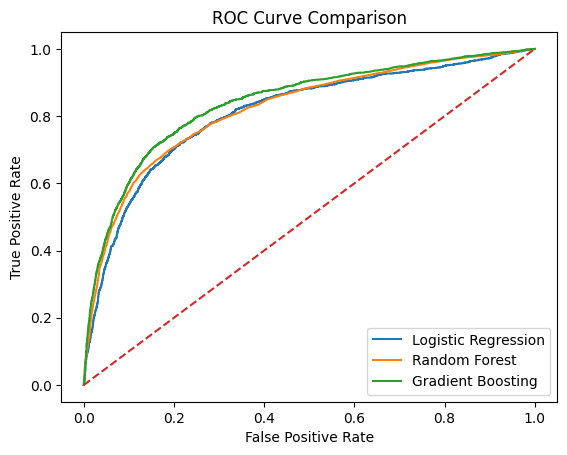

In [7]:
plt.figure()

for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

SHAP for: Logistic Regression


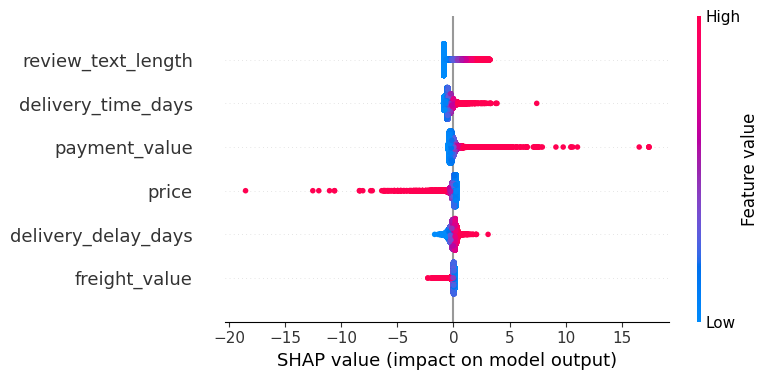

In [8]:
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt
import shap

if shap_available:

    best_model = models[best_model_name]

    print("SHAP for:", best_model_name)

    # =========================
    # Tree models
    # =========================
    if best_model_name in ["Random Forest", "Gradient Boosting"]:

        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test)

        shap.summary_plot(shap_values, X_test)   # ❗ без show=True
        plt.show()

    # =========================
    # Linear model
    # =========================
    elif best_model_name == "Logistic Regression":

        explainer = shap.LinearExplainer(best_model, X_train)
        shap_values = explainer.shap_values(X_test)

        shap.summary_plot(shap_values, X_test)   # ❗ без show=True
        plt.show()

    # =========================
    # fallback
    # =========================
    else:

        explainer = shap.Explainer(best_model, X_train)
        shap_values = explainer(X_test)

        shap.plots.beeswarm(shap_values)
        plt.show()